In [ ]:
# Install the required packages
!pip install rasterio
!pip install geopandas
!pip install matplotlib
!pip install numpy
!pip install pandas


import rasterio
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# For charts to be displayed in the notebook
%matplotlib inline


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 34.2 MB/s eta 0:00:00


In [ ]:
data_path = '/content/LC09_L2SP_044034_20221213_20230411_02_T1_ST_B10.TIF'
# Reading raster data
st_band = rasterio.open(data_path)
# Convert raster data to numpy array
st_data = st_band.read(1).astype(float)

# Summary of data
print(st_band.profile)

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 7671, 'height': 7791, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(30.0, 0.0, 461985.0,
       0.0, -30.0, 4264215.0), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}


In [ ]:
# Masking NoData values
nodata_value = st_band.nodata
if nodata_value is not None:
    st_data = np.ma.masked_equal(st_data, nodata_value)
else:
     # If NoData is not specified, mask the value 0
    st_data = np.ma.masked_equal(st_data, 0)


In [ ]:
# Scaling factor and insertion coefficient
scale_factor = 0.00341802  # TEMPERATURE_MULT_BAND_ST_B10
add_offset = 149.0         # TEMPERATURE_ADD_BAND_ST_B10

# Calculate actual temperature values (Kelvin)
real_temp_k = (st_data * scale_factor) + add_offset

# Convert Kelvin to Celsius
real_temp_c = real_temp_k - 273.15


In [ ]:
print(f"Sıcaklık değerleri (°C): min={real_temp_c.min():.2f}, max={real_temp_c.max():.2f}")


Sıcaklık değerleri (°C): min=-19.32, max=26.38


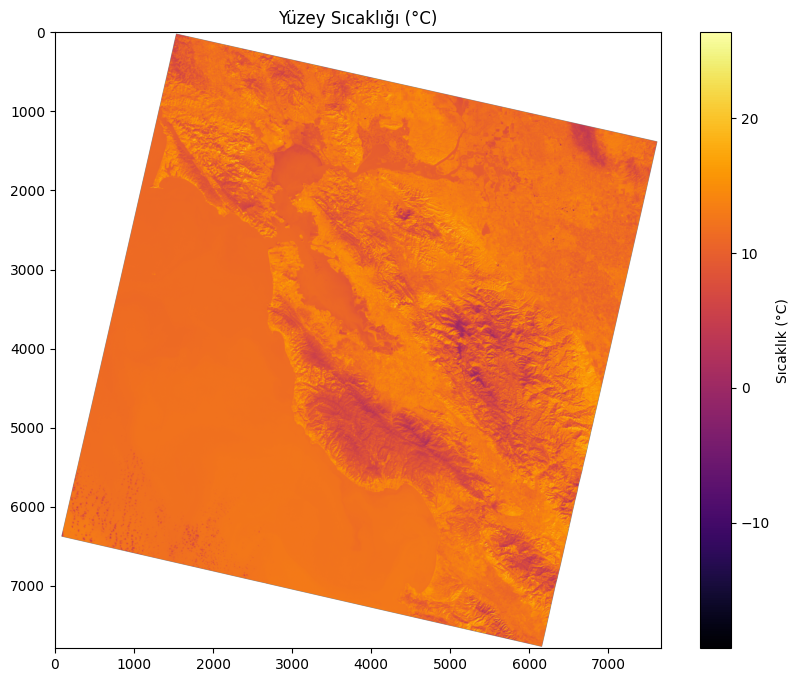

In [ ]:
# Setting the map size
plt.figure(figsize=(10, 8))

# Visualizing temperature data
# Create a mappable object using 'imshow' instead of 'show'
plt.imshow(real_temp_c, cmap='inferno')


plt.title('Yüzey Sıcaklığı (°C)')


plt.colorbar(label='Sıcaklık (°C)')
plt.show()



In [ ]:
# Flatten current data to an array
temp_values = real_temp_c.compressed()

# Statistical values
mean_temp = np.mean(temp_values)
median_temp = np.median(temp_values)
std_temp = np.std(temp_values)

print(f"Ortalama Sıcaklık: {mean_temp:.2f} °C")
print(f"Medyan Sıcaklık: {median_temp:.2f} °C")
print(f"Standart Sapma: {std_temp:.2f}")


Ortalama Sıcaklık: 11.60 °C
Medyan Sıcaklık: 11.88 °C
Standart Sapma: 2.10


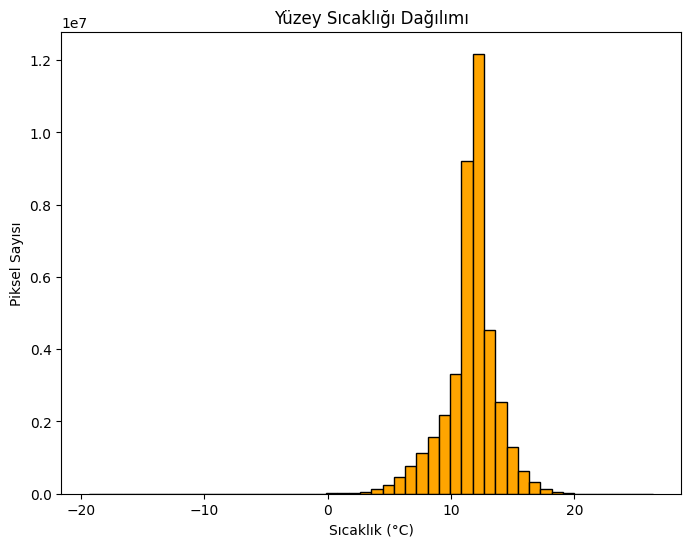

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(temp_values, bins=50, color='orange', edgecolor='black')
plt.title('Yüzey Sıcaklığı Dağılımı')
plt.xlabel('Sıcaklık (°C)')
plt.ylabel('Piksel Sayısı')
plt.show()
